In [1]:
import pandas as pd
import numpy as np
import json

df=pd.read_csv("Karachi_UHI_Final_Data.csv")
df.head()

,system:index,LST,NDBI,NDVI,date,.geo
0,LC08_152042_20200103_7,297.899205,0.067051,0.074174,2020-01-03,"{""type"":""Point"",""coordinates"":[67.421047437658..."
1,LC08_152042_20200103_63,289.251615,0.071787,0.077791,2020-01-03,"{""type"":""Point"",""coordinates"":[67.489386179031..."
2,LC08_152042_20200103_566,298.545211,0.110889,0.081043,2020-01-03,"{""type"":""Point"",""coordinates"":[67.459581003047..."
3,LC08_152042_20200103_975,298.565719,0.097001,0.082107,2020-01-03,"{""type"":""Point"",""coordinates"":[67.447652964502..."
4,LC08_152042_20200119_7,292.710651,0.083992,0.078650,2020-01-19,"{""type"":""Point"",""coordinates"":[67.421047437658..."


In [2]:
df['longitude'] = df['.geo'].apply(lambda x: json.loads(x)['coordinates'][0])
df['latitude'] = df['.geo'].apply(lambda x: json.loads(x)['coordinates'][1])

df.drop('.geo', axis=1, inplace=True)
df.head(3)

,system:index,LST,NDBI,NDVI,date,longitude,latitude
0,LC08_152042_20200103_7,297.899205,0.067051,0.074174,2020-01-03,67.421047,25.196251
1,LC08_152042_20200103_63,289.251615,0.071787,0.077791,2020-01-03,67.489386,25.184820
2,LC08_152042_20200103_566,298.545211,0.110889,0.081043,2020-01-03,67.459581,25.197115


In [3]:
df.drop(columns=['system:index'], inplace=True)

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df.drop(columns=['date'], inplace=True)
df.head(3)

,LST,NDBI,NDVI,longitude,latitude,year,month
0,297.899205,0.067051,0.074174,67.421047,25.196251,2020,1
1,289.251615,0.071787,0.077791,67.489386,25.184820,2020,1
2,298.545211,0.110889,0.081043,67.459581,25.197115,2020,1


In [4]:
center_lat = 24.8607
center_lon = 67.0011

df['distance_center'] = np.sqrt(
    (df['latitude'] - center_lat)**2 +
    (df['longitude'] - center_lon)**2
)

df.head(3)

,LST,NDBI,NDVI,longitude,latitude,year,month,distance_center
0,297.899205,0.067051,0.074174,67.421047,25.196251,2020,1,0.537541
1,289.251615,0.071787,0.077791,67.489386,25.184820,2020,1,0.586069
2,298.545211,0.110889,0.081043,67.459581,25.197115,2020,1,0.568665


In [5]:
print("Performing EDA : ")
print(df.describe())
print("\nData Info:")
print(df.info())
print(f"\nDataset shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")



Performing EDA : 
                LST          NDBI          NDVI     longitude      latitude  \
count  91751.000000  91751.000000  91751.000000  91751.000000  91751.000000   
mean     307.073634      0.016603      0.085979     67.079907     24.934806   
std       11.748811      0.074205      0.080417      0.199142      0.174281   
min      150.001480     -0.540106     -0.178920     66.800034     24.601246   
25%      300.520827     -0.008471      0.036847     66.914511     24.776581   
50%      306.420329      0.026344      0.083606     67.029203     24.963403   
75%      315.143116      0.066621      0.125578     67.229552     25.082950   
max      335.613638      0.359462      0.830131     67.499264     25.199699   

               year         month  distance_center  
count  91751.000000  91751.000000     91751.000000  
mean    2021.587743      6.078103         0.258871  
std        1.087132      3.849397         0.121320  
min     2020.000000      1.000000         0.004267  
25%  

CORRELATION WITH LST :
LST                1.000000
NDBI               0.516212
latitude           0.365240
NDVI               0.263729
distance_center    0.130766
longitude          0.115518
month              0.050558
year              -0.033041
Name: LST, dtype: float64

UHI ANALYSIS : 
Urban LST (mean): 300.23K
Rural LST (mean): 310.44K
UHI INTENSITY: -10.21K 



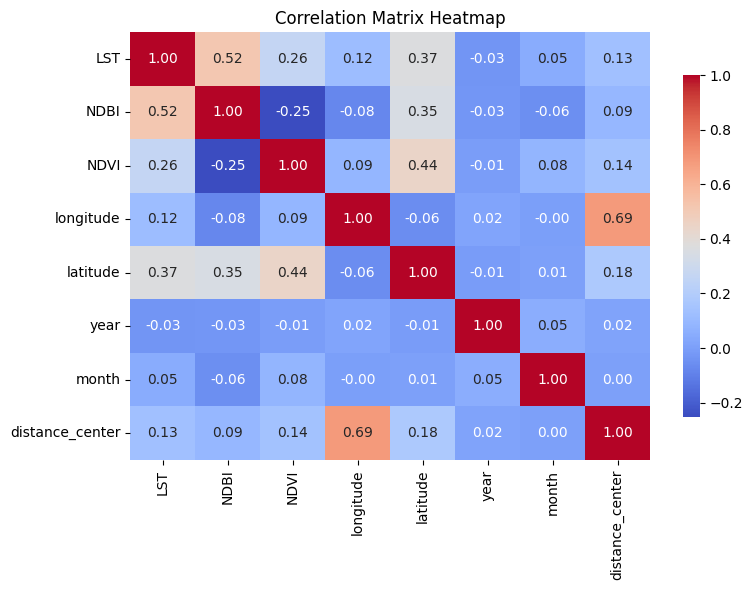

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

print("CORRELATION WITH LST :")
corr = df.corr()['LST'].sort_values(ascending=False)
print(corr)
print()

print("UHI ANALYSIS : ")
ndvi_threshold = df['NDVI'].quantile(0.33)
urban_lst = df[df['NDVI'] < ndvi_threshold]['LST'].mean()
rural_lst = df[df['NDVI'] >= ndvi_threshold]['LST'].mean()
uhi_intensity = urban_lst - rural_lst
print(f"Urban LST (mean): {urban_lst:.2f}K")
print(f"Rural LST (mean): {rural_lst:.2f}K")
print(f"UHI INTENSITY: {uhi_intensity:.2f}K ")
print()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()



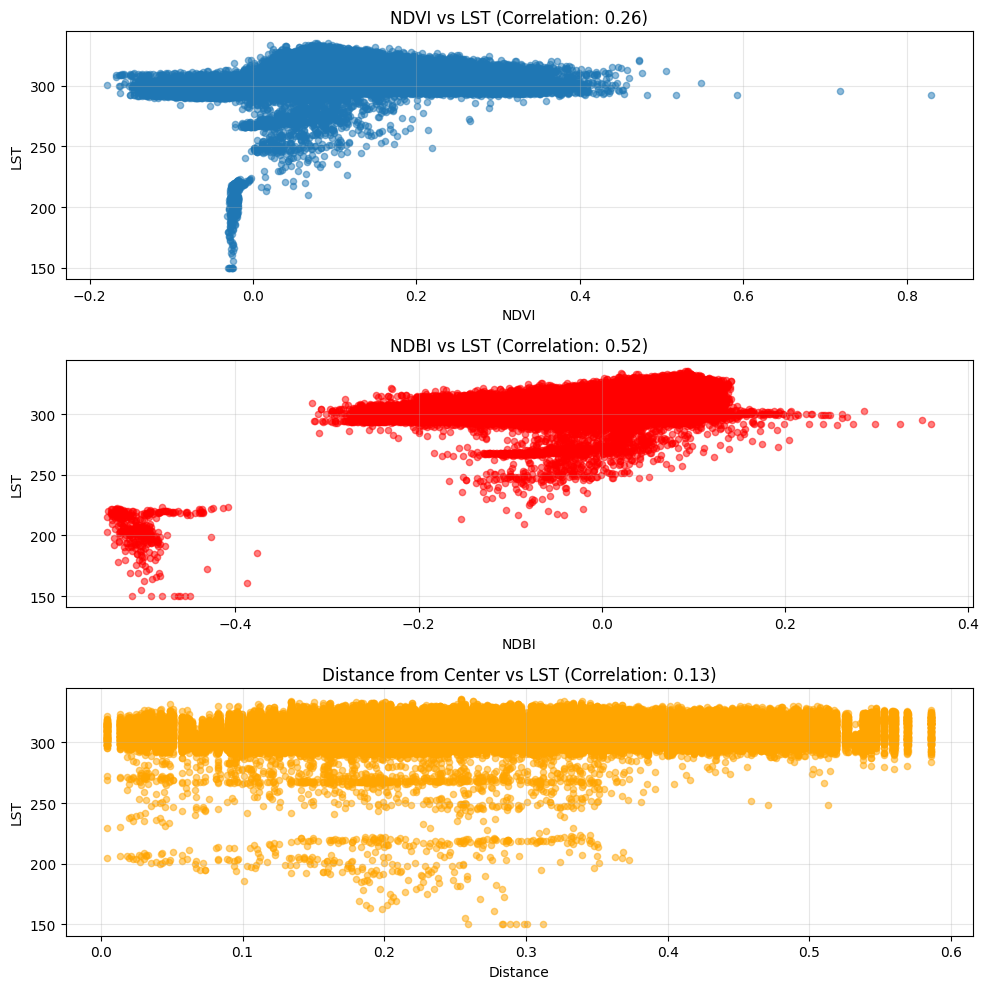

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

axes[0].scatter(df['NDVI'], df['LST'], alpha=0.5, s=20)
axes[0].set_title('NDVI vs LST (Correlation: {:.2f})'.format(df['NDVI'].corr(df['LST'])))
axes[0].set_xlabel('NDVI')
axes[0].set_ylabel('LST')
axes[0].grid(alpha=0.3)

axes[1].scatter(df['NDBI'], df['LST'], alpha=0.5, s=20, color='red')
axes[1].set_title('NDBI vs LST (Correlation: {:.2f})'.format(df['NDBI'].corr(df['LST'])))
axes[1].set_xlabel('NDBI')
axes[1].set_ylabel('LST')
axes[1].grid(alpha=0.3)

axes[2].scatter(df['distance_center'], df['LST'], alpha=0.5, s=20, color='orange')
axes[2].set_title('Distance from Center vs LST (Correlation: {:.2f})'.format(df['distance_center'].corr(df['LST'])))
axes[2].set_xlabel('Distance')
axes[2].set_ylabel('LST')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("DATA PREPARATION :")
input = df[['NDVI', 'NDBI', 'distance_center', 'month', 'year']]
target = df['LST']
print(f"Features: {input.shape}")
print(f"Target: {target.shape}")

X_train, X_test, y_train, y_test = train_test_split(input, target, test_size=0.2, random_state=42)
print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


DATA PREPARATION :
Features: (91751, 5)
Target: (91751,)

Train set: (73400, 5)
Test set: (18351, 5)


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=input.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=input.columns)

print("Scaled Train Data :")
print(X_train_scaled.head(3))

Scaled Train Data :
       NDVI      NDBI  distance_center     month      year
0  0.291018  0.474446        -0.119365  0.761582  1.299252
1 -1.105347 -0.915219        -1.165003 -1.316102 -1.459782
2 -0.066396  0.774512         0.210205 -1.056392 -0.540104


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MODEL TRAINING & EVALUATION : ")
results = {}

print("\n1. LINEAR REGRESSION")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

results['Linear Regression'] = {'R²': r2_lr, 'RMSE': rmse_lr, 'MAE': mae_lr}
print(f"R² Score: {r2_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")



MODEL TRAINING & EVALUATION : 

1. LINEAR REGRESSION
R² Score: 0.4023
RMSE: 8.6758
MAE: 6.5620


In [12]:
print("\n2. RANDOM FOREST")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

results['Random Forest'] = {'R²': r2_rf, 'RMSE': rmse_rf, 'MAE': mae_rf}
print(f"R² Score: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")



2. RANDOM FOREST
R² Score: 0.8409
RMSE: 4.4755
MAE: 2.7113


In [13]:
import xgboost as xgb

print("\n3. XGBOOST")
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, learning_rate=0.1)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

results['XGBoost'] = {'R²': r2_xgb, 'RMSE': rmse_xgb, 'MAE': mae_xgb}
print(f"R² Score: {r2_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")

print("\nALL MODELS COMPARISON : ")
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R²', ascending=False)
print(results_df)




3. XGBOOST
R² Score: 0.8038
RMSE: 4.9711
MAE: 3.0983

ALL MODELS COMPARISON : 
                         R²      RMSE       MAE
Random Forest      0.840931  4.475530  2.711339
XGBoost            0.803757  4.971062  3.098310
Linear Regression  0.402259  8.675781  6.561970


In [14]:
feature_imp_lr = pd.DataFrame({
    'Feature': input.columns,
    'Coefficient': lr.coef_
})

print("Linear Regression Feature Importance :")
print(feature_imp_lr)

feature_imp_rf = pd.DataFrame({
    'Feature': input.columns,
    'Importance': rf.feature_importances_
})
print("\nRandom Forest Feature Importance:")
print(feature_imp_rf)

feature_imp_xgb = pd.DataFrame({
    'Feature': input.columns,
    'Importance': xgb_model.feature_importances_
})
print("\nXGBoost Feature Importance:")
print(feature_imp_xgb)


Linear Regression Feature Importance :
           Feature  Coefficient
0             NDVI     4.908837
1             NDBI     7.451056
2  distance_center     0.169788
3            month     0.606475
4             year    -0.185858

Random Forest Feature Importance:
           Feature  Importance
0             NDVI    0.244638
1             NDBI    0.441621
2  distance_center    0.066350
3            month    0.214881
4             year    0.032510

XGBoost Feature Importance:
           Feature  Importance
0             NDVI    0.210722
1             NDBI    0.453246
2  distance_center    0.019283
3            month    0.264683
4             year    0.052066


In [15]:
print("MODEL PREDICTIONS VISUALIZATION : ")
y_pred_best = y_pred_xgb
print("\nSample Predictions (XGBoost):")

comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_best[:10],
    'Error': abs(y_test.values[:10] - y_pred_best[:10])
})
print(comparison)

residuals = y_test.values - y_pred_best
print(f"\nResidual Statistics:")
print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Dev: {residuals.std():.4f}")
print(f"Min: {residuals.min():.4f}")
print(f"Max: {residuals.max():.4f}")



MODEL PREDICTIONS VISUALIZATION : 

Sample Predictions (XGBoost):
       Actual   Predicted     Error
0  296.870381  296.318573  0.551808
1  297.970984  298.647522  0.676538
2  306.943286  309.989044  3.045758
3  309.004352  306.217926  2.786426
4  299.888493  302.856171  2.967678
5  304.290903  301.337769  2.953134
6  315.539606  308.296844  7.242762
7  321.435691  313.788666  7.647025
8  301.426602  305.769836  4.343235
9  299.926091  302.364380  2.438289

Residual Statistics:
Mean Residual: -0.0414
Std Dev: 4.9709
Min: -68.3368
Max: 35.0375


In [18]:
print("PREDICT LST FOR NEW LOCATIONS :")
new_data = pd.DataFrame({
    'NDVI': [0.05, 0.15, 0.25],
    'NDBI': [0.10, 0.05, 0.3],
    'distance_center': [0.5, 1.0, 2.0],
    'month': [7, 10, 9],
    'year': [2023, 2024, 2025]
})

print("New Data : ")
print(new_data)
new_data_scaled = scaler.transform(new_data)
predictions = xgb_model.predict(new_data)

results_new = pd.DataFrame({
    'NDVI': new_data['NDVI'],
    'NDBI': new_data['NDBI'],
    'Distance': new_data['distance_center'],
    'Predicted_LST': predictions
})

print("\nPredictions:")
print(results_new)



PREDICT LST FOR NEW LOCATIONS :
New Data : 
   NDVI  NDBI  distance_center  month  year
0  0.05  0.10              0.5      7  2023
1  0.15  0.05              1.0     10  2024
2  0.25  0.30              2.0      9  2025

Predictions:
   NDVI  NDBI  Distance  Predicted_LST
0  0.05  0.10       0.5     317.962494
1  0.15  0.05       1.0     313.973083
2  0.25  0.30       2.0     303.767181
